In [13]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd

from matplotlib import rcParams
# Use Arial for all math text
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Helvetica"
plt.rcParams["mathtext.it"] = "Helvetica:italic"
plt.rcParams["mathtext.bf"] = "Helvetica:bold"

# Use Arial for all normal text
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

In [14]:
nat_blue   = (74/255, 111/255, 165/255)   # Mediterranean sky blue
res_red    = (200/255, 74/255, 61/255)    # Vermilion / poppy red
line_brown  = (139/255, 107/255, 79/255)   # Warm umber earth
line_green  = (111/255, 143/255, 94/255)   # Olive landscape green
line_purple = (106/255, 76/255, 125/255)   # Muted aubergine purple
all_lake_neutral = (28/255, 24/255, 20/255)
grey_background = (235/255, 233/255, 228/255)

In [19]:
all_lakes_pop = pd.read_csv("all_lakes_population_histogram_max_105km_bin_5km.csv")
nat_pop = pd.read_csv("Natural Lake_population_histogram_max_105km_bin_5km.csv")
res_pop = pd.read_csv("Reservoir_population_histogram_max_105km_bin_5km.csv")

In [20]:
## Fig 1b
# --- Load data (CSV with header) ---
df_declustered = pd.read_csv("../../Processed_Data/Declustered_Events_withClosestLake_depth30.txt", sep = '\t')

closestDist_km = df_declustered["ClosestLakeDist_km"].to_numpy()

# --- Distance bin edges (km): 0:50:500 ---
bins = np.arange(0, 501, 50)  # includes 500

# --- Counts per bin ---
counts, edges = np.histogram(closestDist_km, bins=bins)

# --- "Number of lakes" multiplier (analogous to length(X_Lake) in MATLAB) ---
# If you don't have X_Lake loaded, a reasonable proxy from this file is the number of unique lake IDs:
n_lakes = df_declustered["ClosestLakeID"].nunique()

# --- Annulus areas (km^2) ---
r1 = edges[:-1]
r2 = edges[1:]
area = np.pi * (r2**2 - r1**2) * n_lakes

# --- Years spanned by catalog (edit if needed) ---
total_yr = 2019 - 1992 + 1

# --- Rate density: events / (yr * km^2) ---
density = counts / area / total_yr
binCenters = (r1 + r2) / 2

In [21]:
# Load data
df_peak = pd.read_csv("../../Processed_Data/Lake_maximum_storgae_change.txt", sep="\t")

# Split by lake type
all_lakes = df_peak["MaxStorageChange_Gt"].dropna().abs().values
res = df_peak[df_peak["LakeType"] == "Reservoir"]["MaxStorageChange_Gt"].dropna().abs().values
nat = df_peak[df_peak["LakeType"] == "NaturalLake"]["MaxStorageChange_Gt"].dropna().abs().values

all_lakes_log10 = np.log10(all_lakes)
res_log10 = np.log10(res)
nat_log10 = np.log10(nat)

# Number of bins
bin_width = 0.2   # example: 1 in log10 space
bins = np.arange(-3,
                 3 + bin_width,
                 bin_width)

# Histogram counts
counts_all_lakes, bin_edges_all_lakes = np.histogram(all_lakes_log10, bins=bins)
counts_res, bin_edges_res = np.histogram(res_log10, bins=bins)
counts_nat, bin_edges_nat = np.histogram(nat_log10, bins=bins)

# Relative frequency per bin
rel_freq_all_lakes = counts_all_lakes / len(all_lakes_log10)
rel_freq_res = counts_res / len(res_log10)
rel_freq_nat = counts_nat / len(nat_log10)

# Plot
w_all_lakes = np.ones_like(all_lakes_log10) / len(all_lakes_log10)
w_res = np.ones_like(res_log10) / len(res_log10)
w_nat = np.ones_like(nat_log10) / len(nat_log10)

# plt.hist(all_lakes_log10, bins=bins, histtype="step", linewidth=1.5, weights=w_all_lakes, edgecolor = all_lake_neutral)
# plt.hist(res_log10, bins=bins, histtype="step", linewidth=1.5, weights=w_res, edgecolor = res_red)
# plt.hist(nat_log10, bins=bins, histtype="step", linewidth=1.5, weights=w_nat, edgecolor = nat_blue)
# plt.ylabel("Relative frequency")

In [22]:
# Load data
df_lake_trends = pd.read_csv(
    "../../Processed_Data/WaterStorageTrend.txt",
    sep=r"\s+",        # whitespace-separated
    comment="#"
)

# Colors (converted from MATLAB RGB/255)
color_pos = (213/255, 118/255, 107/255)
color_neg = (168/255, 200/255, 228/255)

In [23]:
## Fig 1d

# -----------------------------
# READ DATA
# -----------------------------
df_cum_all = pd.read_csv('../../Processed_Data/Cumulative_EQ_vs_Time_All_depth30.txt', sep=r"\s+")

# Extract columns
time_20_all = df_cum_all["Time_20km"].values
cum_20_all = df_cum_all["CumEQ_20km"].values

time_100_all = df_cum_all["Time_100km"].values
cum_100_all = df_cum_all["CumEQ_100km"].values

df_cum_re = pd.read_csv('../../Processed_Data/Cumulative_EQ_vs_Time_Reservoir_depth30.txt', sep=r"\s+")

# Extract columns
time_20_re = df_cum_re["Time_20km"].values
cum_20_re = df_cum_re["CumEQ_20km"].values

time_100_re = df_cum_re["Time_100km"].values
cum_100_re = df_cum_re["CumEQ_100km"].values

df_cum_na = pd.read_csv('../../Processed_Data/Cumulative_EQ_vs_Time_Natural_depth30.txt', sep=r"\s+")

# Extract columns
time_20_na = df_cum_na["Time_20km"].values
cum_20_na = df_cum_na["CumEQ_20km"].values

time_100_na = df_cum_na["Time_100km"].values
cum_100_na = df_cum_na["CumEQ_100km"].values

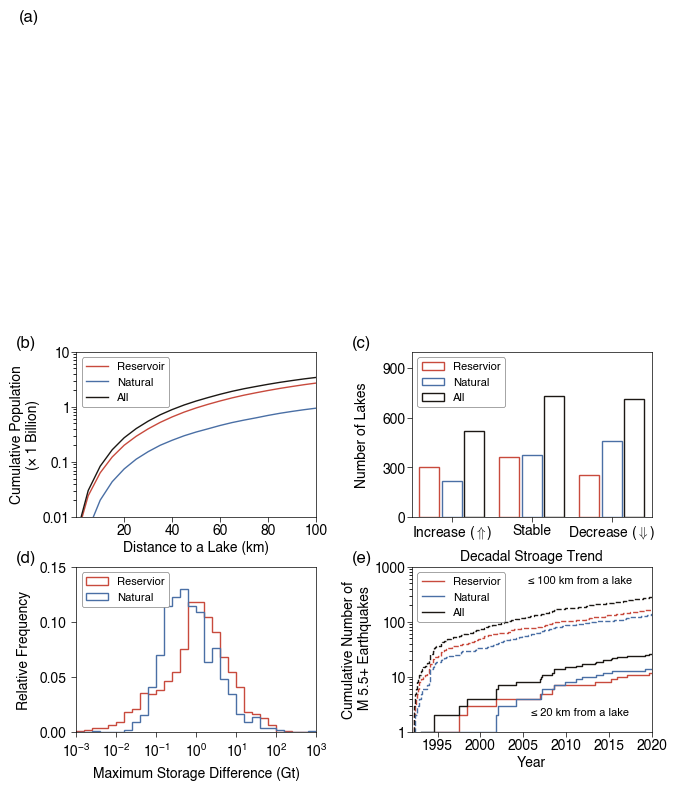

In [24]:
fig = plt.figure(figsize = (6.77, 8))

# 2 columns with exact width ratios: 3/5 and 2/5
gs = GridSpec(
    3, 2,
    figure=fig,
    width_ratios=[1, 1],     # row 2 uses this (left bigger)
    height_ratios=[1.61, 1, 1], # can adjust if needed
    left=0.1, right=0.95,
    bottom=0.08, top=0.95,
    wspace=0.4,
    hspace=0.25
)

# --- Row 1 (full width) ---
ax1 = fig.add_subplot(gs[0, :])     # span both columns

# --- Row 2 (big left, small right) ---
ax5 = fig.add_subplot(gs[1, 0])     # wide
ax2 = fig.add_subplot(gs[1, 1])     # narrow

# --- Row 3 (equal size) ---
ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[2, 1])

# -----------------------------
# Number of Lakes
# -----------------------------

# --- Example data (replace with your values) ---
categories = [ r"Increase ($\Uparrow$)", "Stable", r"Decrease ($\Downarrow$)"]   # clusters on x-axis

# total is 1971?

values_1 = np.array([304, 362, 255])
values_2 = np.array([217, 373, 460])
values_3 = np.array([521, (362 + 373), 715])

# --- Bar positions ---
x_bar = np.arange(len(categories))
width_bar = 0.25   # width of each bar
shrink = 1.125

ax2.bar(x_bar - width_bar*shrink, values_1, width_bar, label="Reservior",facecolor="none", edgecolor = res_red,linewidth = 1)
ax2.bar(x_bar, values_2, width_bar, label="Natural", facecolor='none', edgecolor = nat_blue,linewidth = 1)
ax2.bar(x_bar + width_bar*shrink, values_3, width_bar, label="All",facecolor="none", edgecolor = all_lake_neutral,linewidth = 1)

# --- Formatting ---
ax2.set_xticks(x_bar)
ax2.set_xticklabels(categories, fontsize=10)
ax2.tick_params(axis='x', pad = 1)
ax2.tick_params(axis='y', pad = 1)
ax2.set_ylabel("Number of Lakes", fontsize=10, labelpad=10)
ax2.set_xlabel("Decadal Stroage Trend", fontsize=10, labelpad=6)
ax2.set_xlim(min(x_bar- 2*width_bar), max(x_bar+ 2*width_bar))
ax2.set_ylim(0, 1000)
ax2.set_yticks(np.arange(0, 1000, 300))
leg2 = ax2.legend(fontsize=8, loc="upper left")

# Control legend frame appearance
frame2 = leg2.get_frame()
frame2.set_alpha(1)       # transparency
frame2.set_linewidth(0.5)   # frame thickness
frame2.set_edgecolor("grey")

# -----------------------------
# peak to peak difference
# -----------------------------


ax3.hist(res_log10, bins=bins, histtype="step", linewidth=1, weights=w_res, edgecolor = res_red, label="Reservior")
ax3.hist(nat_log10, bins=bins, histtype="step", linewidth=1, weights=w_nat, edgecolor = nat_blue, label="Natural")
# ax3.hist(all_lakes_log10, bins=bins, histtype="step", linewidth=1, weights=w_all_lakes, edgecolor = all_lake_neutral, label="All")

ax3.set_xlabel("Maximum Storage Difference (Gt)", labelpad=5)
ax3.set_ylabel("Relative Frequency", labelpad=6)
ax3.set_ylim(0,0.15)
ax3.set_xticks(np.arange(-3,4,1))
ax3.set_xticklabels([r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"])
ax3.set_xlim(-3,3)

leg3 = ax3.legend(fontsize=8, loc = 'upper left')
# Control legend frame appearance
frame3 = leg3.get_frame()
frame3.set_alpha(1)       # transparency
frame3.set_linewidth(0.5)   # frame thickness
frame3.set_edgecolor("grey")

# -----------------------------
# Earthquake Rate
# -----------------------------

ax4.plot(
    time_20_re,
    cum_20_re,
    linewidth=1,
    color=res_red,
    alpha = 1,
    label="Reservior"
)

ax4.plot(
    time_100_re,
    cum_100_re,
    linewidth=1,
    linestyle = '--',
    color=res_red,
    alpha = 1,
    #label="≤ 100 km"
)


ax4.plot(
    time_20_na,
    cum_20_na,
    linewidth=1,
    color=nat_blue,
    alpha = 1,
    label="Natural"
)

ax4.plot(
    time_100_na,
    cum_100_na,
    linewidth=1,
    linestyle = '--',
    color=nat_blue,
    alpha = 1,
    #label="≤ 100 km"
)

ax4.plot(
    time_20_all,
    cum_20_all,
    linewidth=1,
    color=all_lake_neutral,
    alpha = 1,
    label="All"
)

ax4.plot(
    time_100_all,
    cum_100_all,
    linewidth=1,
    linestyle = '--',
    color=all_lake_neutral,
    alpha = 1,
    #label="≤ 100 km"
)

ax4.set_xlabel("Year", fontsize=10,labelpad = 2)
ax4.set_ylabel("Cumulative Number of\n M 5.5+ Earthquakes", fontsize=10,labelpad=2)

ax4.set_xticks(np.arange(1995, 2025, 5))
ax4.set_xlim(1992, 2020)
ax4.tick_params(axis='x', labelsize=10, pad = 1)
ax4.tick_params(axis='y', labelsize=10, pad = 1)
ax4.set_yscale('log')
ax4.set_ylim(1,1e3)
ax4.set_yticks([1, 10, 100, 1000])
ax4.set_yticklabels(["1","10", "100", "1000"])

leg4 = ax4.legend(fontsize=8, loc = 'upper left')
# Control legend frame appearance
frame4 = leg4.get_frame()
frame4.set_alpha(1)       # transparency
frame4.set_linewidth(0.5)   # frame thickness
frame4.set_edgecolor("grey")

ax4.text(0.7, 0.95, "≤ 100 km from a lake", transform=ax4.transAxes,
         ha="center", va="top", fontsize=8, color='k')

ax4.text(0.7, 0.15, "≤ 20 km from a lake", transform=ax4.transAxes,
         ha="center", va="top", fontsize=8, color='k')


# -----------------------------
# POPULATION PLOT
# -----------------------------

ax5.plot(
    res_pop['distance_km'],
    res_pop['population'].cumsum(),
    linewidth=1,
    linestyle = '-',
    color=res_red,
    alpha = 1,
    label="Reservoir"
)

ax5.plot(
    nat_pop['distance_km'],
    nat_pop['population'].cumsum(),
    linewidth=1,
    linestyle = '-',
    color=nat_blue,
    alpha = 1,
    label="Natural"
)

ax5.plot(
    all_lakes_pop['distance_km'],
    all_lakes_pop['population'].cumsum(),
    linewidth=1,
    linestyle = '-',
    color=all_lake_neutral,
    alpha = 1,
    label="All"
)

ax5.set_xlabel("Distance to a Lake (km)", fontsize=10, labelpad=2)
ax5.set_ylabel("Cumulative Population\n(× 1 Billion)", fontsize=10, labelpad=2)

ax5.set_yscale("log")
ax5.set_ylim(1e7, 1e10)
ax5.set_yticks([1e7, 1e8, 1e9, 1e10])
ax5.set_yticklabels(["0.01","0.1", "1", "10"])

ax5.set_xlim(0, 100)
ax5.set_xticks(np.arange(20, 101, 20))
ax5.tick_params(labelsize=10, pad=1, width=0.5)

leg5 = ax5.legend(fontsize=8, loc = 'upper left')
# Control legend frame appearance
frame5 = leg5.get_frame()
frame5.set_alpha(1)       # transparency
frame5.set_linewidth(0.5)   # frame thickness
frame5.set_edgecolor("grey")

### NUMBERS ###
for ax in [ax1, ax2, ax3, ax4, ax5]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)  # match tick thickness to frame


### Frame Style ###
for ax, label in [(ax5, '(b)'), (ax2, '(c)'), (ax3, '(d)'), (ax4, '(e)')]:
    ax.text(-0.25, 1.1, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=12, fontweight='bold', clip_on=False)

# Keep the frame (spines)
for spine in ax1.spines.values():
    spine.set_linewidth(0)
# Remove all plotted content
ax1.cla()

ax1.text(-0.1, 1.1, '(a)',# transform=ax1.transAxes,
            ha="left", va="top", fontsize=12, fontweight='bold', clip_on=False)

# Remove ticks and labels
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(
    left=False, bottom=False,
    labelleft=False, labelbottom=False
)
# Save for submission
plt.savefig("fig1_bcd.pdf", dpi=300)
plt.savefig("fig1_bcd.png", dpi=300)
plt.show()